# Exploratory Storyboarding

Up to this point, we have learned how to build individual, highly effective charts. But in the real world, a single chart rarely answers a stakeholder's actual question. 

If you hand an executive a pile of 15 disconnected charts, they will get frustrated and ignore them. Your job is not to provide a data dump; your job is to tell a cohesive, logical story. In this lesson, we learn how to sequence our visualizations into an **Analytical Narrative**.

An effective data storyboard follows a strict psychological sequence. You are taking the viewer on a journey from "What is happening?" all the way to "What should we do about it?"

**The 3-Part Storyboard Framework:**
1. **The Context (The 'What')**: A high-level, aggregate metric (KPI) over time. This establishes the baseline and highlights the core problem.
2. **The Isolation (The 'Where')**: A categorical breakdown. Now that we know there is a problem, where exactly is it happening? Which region, product, or team is responsible?
3. **The Root Cause (The 'Why')**: A scatterplot, correlation, or behavioral chart that explains the underlying driver of the problem.

Let's use Python's `matplotlib.gridspec` to build a single, unified storyboard layout rather than printing three separate charts!

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="white")

# 1. Simulate a Customer Churn Dataset
np.random.seed(42)

# Context Data: Monthly Churn Rate over the year
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
overall_churn = [2.1, 2.0, 2.2, 2.1, 2.4, 2.8, 3.5, 4.2, 4.0, 4.5, 4.8, 5.0]

# Isolation Data: Churn by Subscription Tier (Current Month)
tiers = ['Basic', 'Pro', 'Enterprise']
tier_churn = [8.5, 3.2, 1.1]

# Root Cause Data: Customer Service Wait Times vs Churn Probability
wait_times = np.random.uniform(1, 45, 100) # Wait time in minutes
churn_prob = (wait_times * 0.15) + np.random.normal(0, 2, 100)
churn_prob = np.clip(churn_prob, 0, 15) # Keep percentages realistic

print("✅ Customer Churn Dataset loaded!")

✅ Customer Churn Dataset loaded!


# 1. Building the Layout (GridSpec)
Instead of plotting charts one below the other, we want to create a "Dashboard" feel. We want the high-level context spanning the entire top row, and the two drill-down charts sitting side-by-side on the bottom row.

We use `GridSpec`, which allows us to create custom grid layouts for our subplots.

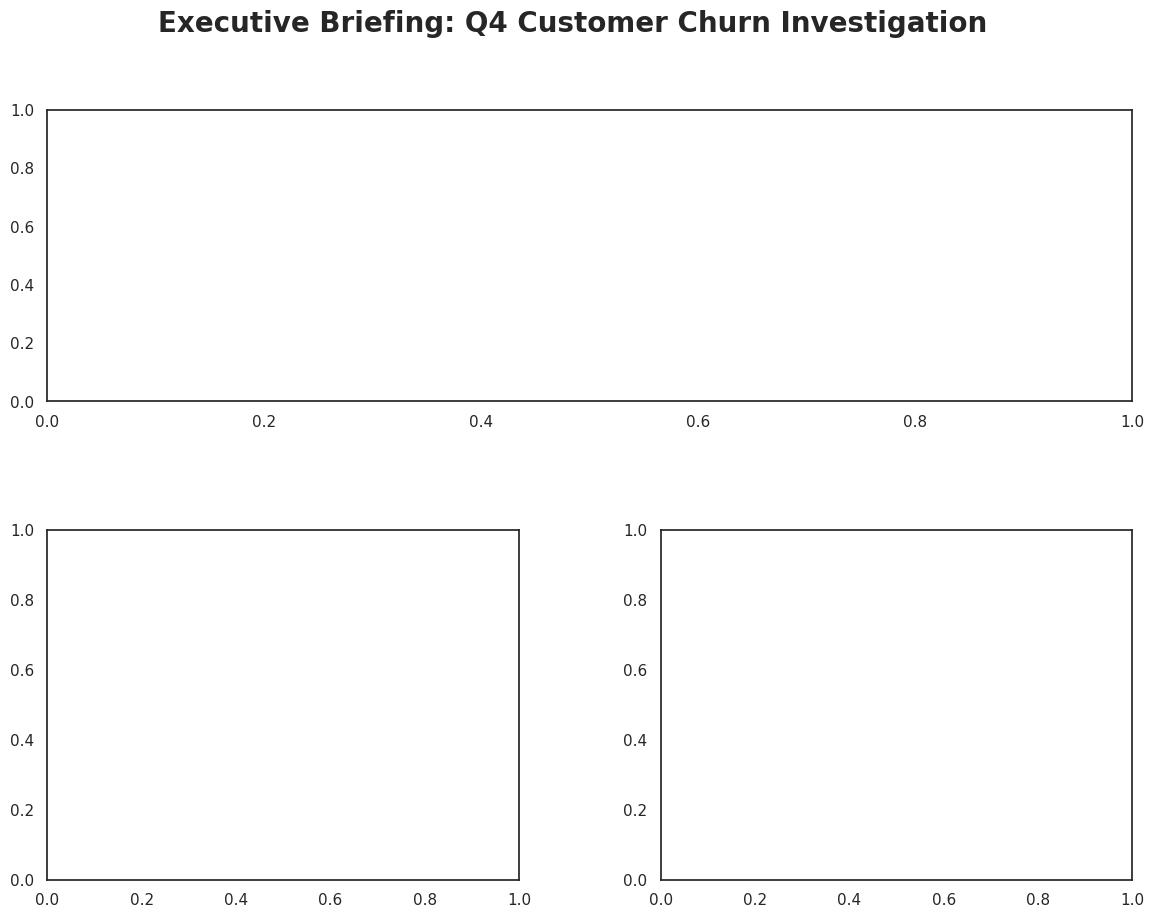

✅ Blank Storyboard Grid Created!


In [8]:
# Create a large figure to hold our storyboard
fig = plt.figure(figsize=(14, 10))

# Define a grid with 2 rows and 2 columns
# height_ratios=[1, 1.2] makes the bottom row slightly taller
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.4, wspace=0.3)

# Assign our specific subplots to the grid
ax1 = fig.add_subplot(gs[0, :])  # Row 0, spans all columns (Context)
ax2 = fig.add_subplot(gs[1, 0])  # Row 1, Column 0 (Isolation)
ax3 = fig.add_subplot(gs[1, 1])  # Row 1, Column 1 (Root Cause)

# Add a Master Title for the entire storyboard
fig.suptitle("Executive Briefing: Q4 Customer Churn Investigation", 
             fontsize=20, fontweight='bold', ha='center', y=0.98)

plt.show()
print("✅ Blank Storyboard Grid Created!")

# 2. Populating the Story (The Narrative Arc)
Now we fill our layout with the three stages of our framework. We will use the design principles from Lesson 03 (Color, Layout, Accessibility) to make the message impossible to miss.

/tmp/ipykernel_4172/2755975918.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=months, y=overall_churn, ax=ax1, palette=colors)
/tmp/ipykernel_4172/2755975918.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tiers, y=tier_churn, ax=ax2, palette=['#d73027', 'gray', 'gray'])


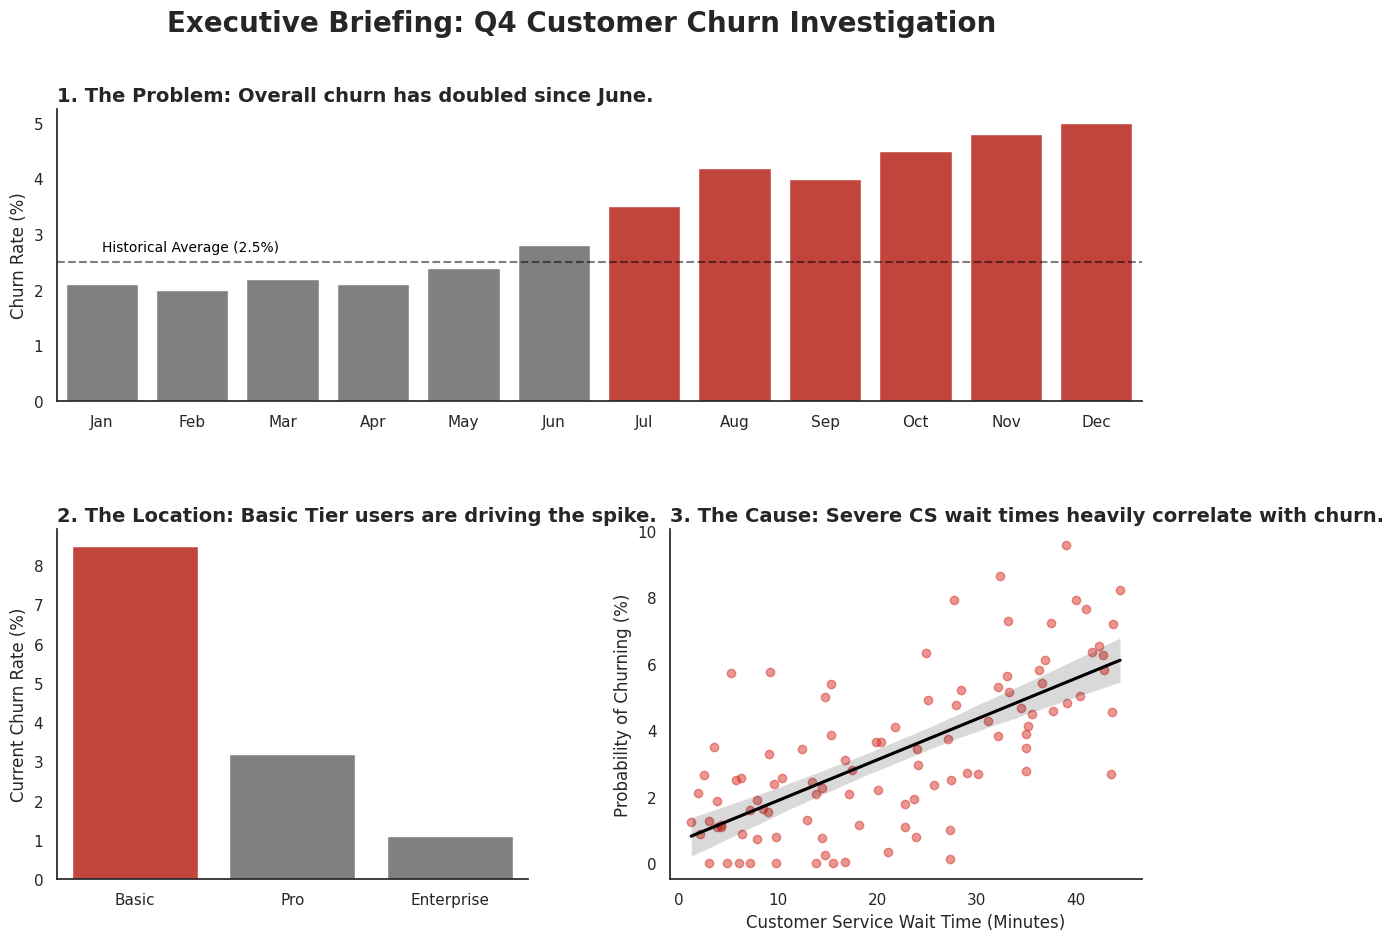

In [11]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2],
                       hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle("Executive Briefing: Q4 Customer Churn Investigation",
             fontsize=20, fontweight='bold', y=0.98)
# ---------------------------------------------------------
# ACT 1: THE CONTEXT (The 'What') - Spans the top row
# ---------------------------------------------------------
# We plot the trend over time. We use gray for normal months, and RED for the crisis months.
colors = ['gray' if x < 6 else '#d73027' for x in range(len(months))]
sns.barplot(x=months, y=overall_churn, ax=ax1, palette=colors)

ax1.set_title("1. The Problem: Overall churn has doubled since June.", fontsize=14, fontweight='bold', loc='left')
ax1.set_ylabel("Churn Rate (%)")
ax1.axhline(2.5, color='black', linestyle='--', alpha=0.5)
ax1.text(0, 2.7, 'Historical Average (2.5%)', color='black', fontsize=10)
sns.despine(ax=ax1)

# ---------------------------------------------------------
# ACT 2: THE ISOLATION (The 'Where') - Bottom Left
# ---------------------------------------------------------
# We break the latest month down by tier. We highlight 'Basic' in red to show where the bleeding is.
sns.barplot(x=tiers, y=tier_churn, ax=ax2, palette=['#d73027', 'gray', 'gray'])

ax2.set_title("2. The Location: Basic Tier users are driving the spike.", fontsize=14, fontweight='bold', loc='left')
ax2.set_ylabel("Current Churn Rate (%)")
sns.despine(ax=ax2)

# ---------------------------------------------------------
# ACT 3: THE ROOT CAUSE (The 'Why') - Bottom Right
# ---------------------------------------------------------
# We use a scatterplot with a trendline to prove WHY the Basic users are leaving.
sns.regplot(x=wait_times, y=churn_prob, ax=ax3, color='#d73027', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'black'})

ax3.set_title("3. The Cause: Severe CS wait times heavily correlate with churn.", fontsize=14, fontweight='bold', loc='left')
ax3.set_xlabel("Customer Service Wait Time (Minutes)")
ax3.set_ylabel("Probability of Churning (%)")
sns.despine(ax=ax3)

# Render the final storyboard!
plt.show()

*(Insight: Imagine handing this 3-part visual to a CEO. They don't need to ask you any questions. They instantly see that churn is up (Act 1), it is entirely coming from the cheapest subscription tier (Act 2), and it is being caused by terrible customer service wait times (Act 3). The logical "Next Step" is immediately obvious: Hire more customer service reps for the Basic tier!)*

---

## Real-World Use Case or Analogy:
Think of Exploratory Storyboarding like **Investigating a Factory Defect**:

* **The Context (The Yield Report)**: The Plant Manager looks at the daily yield report. The defect rate has suddenly jumped from the standard 2% up to a critical 9%. This is the "What". The manager knows they are losing money, but they don't know where to look in the massive factory.
* **The Isolation (The Assembly Line Breakdown)**: The engineers slice the defect data by the 4 different assembly lines. They discover that Lines A, B, and C have a normal 2% defect rate, but Line D has a massive 30% defect rate. This is the "Where". They isolate the factory and walk directly over to Line D.
* **The Root Cause (The Machine Calibration)**: Standing at Line D, the engineers look at the sensor logs. They create a scatterplot mapping "Machine Vibration" against "Defect Occurrence". They find a perfect, steep correlation. This is the "Why". A specific motor is vibrating too heavily and ruining the product.
* **The Result**: The story is complete. The problem was identified, isolated, and diagnosed. The Call to Action is clear: Replace the motor on Line D.

---